Loading index...
Index loaded: 12,491,905 vectors
Loading metadata...
Loading CLIP models...
Encoding query image...
Searching...

Saved → ./datacomp/query_result.png
URL: https://www.sehat.com/article_images/1489485041.jpg
Caption: Cat scratch disease Causes, Symptoms and Treatment
Cosine similarity: 0.8386


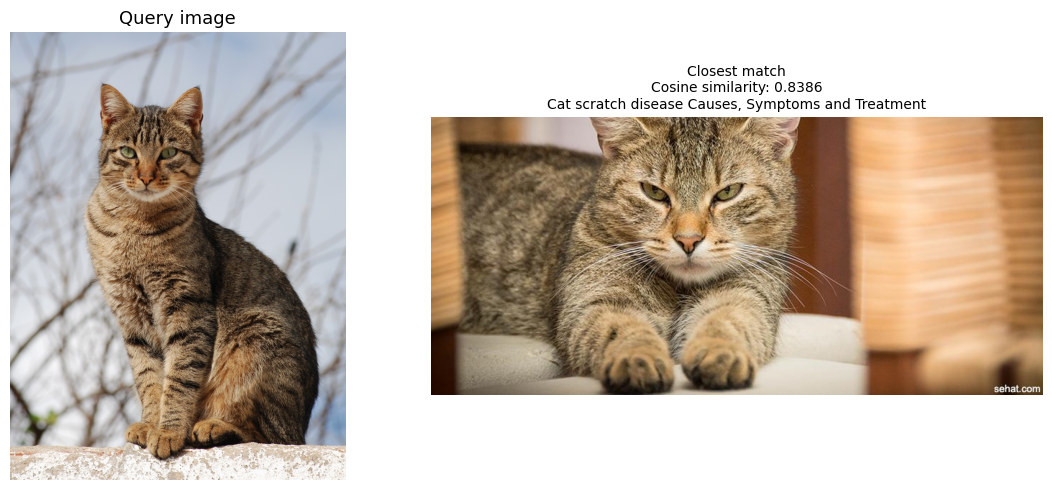

In [7]:
import numpy as np
import faiss
import open_clip
import torch
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

SAVE_DIR = "./datacomp"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Load resources ────────────────────────────────────────────────────────────
print("Loading index...")
index = faiss.read_index(f"{SAVE_DIR}/index.faiss")
index.nprobe = 64
print(f"Index loaded: {index.ntotal:,} vectors")

print("Loading metadata...")
faiss_uids = np.load(f"{SAVE_DIR}/faiss_uids.npy", allow_pickle=True)
metadata_df = pd.read_parquet(f"{SAVE_DIR}/metadata.parquet", columns=["uid", "url", "caption"])
metadata_df = metadata_df.set_index("uid")


print("Loading CLIP models...")
model1, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14", pretrained="datacomp_xl_s13b_b90k"
)
model2, _, _ = open_clip.create_model_and_transforms(
    "ViT-L-14-quickgelu", pretrained="openai"
)
model1.eval().to(DEVICE)
model2.eval().to(DEVICE)

# ── Encode query image ────────────────────────────────────────────────────────
print("Encoding query image...")
query_img = Image.open(f"{SAVE_DIR}/image.jpg").convert("RGB")
img_tensor = preprocess(query_img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    e1 = model1.encode_image(img_tensor)  # datacomp
    e2 = model2.encode_image(img_tensor)  # openai
    e1 = e1 / e1.norm(dim=-1, keepdim=True)
    e2 = e2 / e2.norm(dim=-1, keepdim=True)
    query_emb = torch.cat([e2, e1], dim=-1).cpu().numpy().astype(np.float32)  # openai first

faiss.normalize_L2(query_emb)

# ── Search ────────────────────────────────────────────────────────────────────
print("Searching...")
D, I = index.search(query_emb, k=10)  # get top 10, pick first that loads

# ── Find first result whose URL actually loads ────────────────────────────────
result_img = None
result_url = None
result_dist = None
result_caption = None

for dist, idx in zip(D[0], I[0]):
    if idx == -1:
        continue
    row = metadata_df.loc[faiss_uids[idx]]
    url = row["url"]
    try:
        resp = requests.get(url, timeout=5)
        resp.raise_for_status()
        result_img = Image.open(BytesIO(resp.content)).convert("RGB")
        result_url = url
        result_dist = float(dist)
        result_caption = row["caption"]
        break
    except Exception as e:
        print(f"  Could not load {url}: {e}")
        continue

if result_img is None:
    print("None of the top 10 URLs were reachable — saving URLs to check manually:")
    for dist, idx in zip(D[0][:5], I[0][:5]):
        row = metadata_df.loc[faiss_uids[idx]]
        print(f"  dist={dist:.4f}  {row['url']}")
else:
    # ── Display ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(query_img)
    axes[0].set_title("Query image", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(result_img)
    axes[1].set_title(
        f"Closest match\nCosine similarity: {result_dist:.4f}\n{result_caption[:80]}",
        fontsize=10
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/query_result.png", dpi=150, bbox_inches="tight")
    print(f"\nSaved → {SAVE_DIR}/query_result.png")
    print(f"URL: {result_url}")
    print(f"Caption: {result_caption}")
    print(f"Cosine similarity: {result_dist:.4f}")